# ROGII Wellbore Geology Prediction

## Notebook 02 – Exploratory Data Analysis (EDA) of a Selected Well Pair

### Objectives

- Understand the Prediction Start boundary.
- Analyse TVT behaviour before and after Prediction Start.
- Investigate horizontal-well trajectory and GR measurements.
- Compare each horizontal well with its paired typewell.
- Measure missing-data patterns across all training wells.
- Identify useful features and possible data-leakage risks.
- Prepare evidence for feature engineering and model validation.

### 1. Import Libraries

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

### 2. Configure Project Paths

In [2]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
TRAIN_DIR = RAW_DIR / "train"

print("Project root:", PROJECT_ROOT.resolve())
print("Train directory exists:", TRAIN_DIR.exists())

Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Train directory exists: True


### 3. Discover and validate training pairs

In [3]:
typewell_files = sorted(TRAIN_DIR.glob("*_typewell.csv"))
horizontal_files = sorted(TRAIN_DIR.glob("*_horizontal_well.csv"))

typewell_map = {
    file.name.replace("_typewell.csv", ""): file
    for file in typewell_files
}

horizontal_map = {
    file.name.replace("_horizontal_well.csv", ""): file
    for file in horizontal_files
}

typewell_ids = set(typewell_map)
horizontal_ids = set(horizontal_map)

complete_ids = sorted(typewell_ids & horizontal_ids)

print("Typewell files:", len(typewell_files))
print("Horizontal files:", len(horizontal_files))
print("Complete pairs:", len(complete_ids))
print("Missing horizontal wells:", len(typewell_ids - horizontal_ids))
print("Missing typewells:", len(horizontal_ids - typewell_ids))

Typewell files: 773
Horizontal files: 773
Complete pairs: 773
Missing horizontal wells: 0
Missing typewells: 0


### 4. Load one representative pair

In [4]:
sample_id = complete_ids[0]

typewell_path = typewell_map[sample_id]
horizontal_path = horizontal_map[sample_id]

typewell = pd.read_csv(typewell_path)
horizontal = pd.read_csv(horizontal_path)

print("Sample well ID:", sample_id)
print("Typewell shape:", typewell.shape)
print("Horizontal shape:", horizontal.shape)

Sample well ID: 000d7d20_
Typewell shape: (1296, 3)
Horizontal shape: (5278, 13)


In [4]:
sample_typewell_path = typewell_files[0]
sample_horizontal_path = horizontal_files[0]

sample_typewell_path.name, sample_horizontal_path.name

('000d7d20__typewell.csv', '000d7d20__horizontal_well.csv')

### 5. Basic dataset overview

In [5]:
overview = pd.DataFrame({
    "Dataset": ["Typewell", "Horizontal Well"],
    "Rows": [len(typewell), len(horizontal)],
    "Columns": [typewell.shape[1], horizontal.shape[1]],
    "Duplicate Rows": [
        typewell.duplicated().sum(),
        horizontal.duplicated().sum()
    ]
})

display(overview)

print("Typewell columns:")
print(typewell.columns.tolist())

print("\nHorizontal columns:")
print(horizontal.columns.tolist())

,Dataset,Rows,Columns,Duplicate Rows
0,Typewell,1296,3,0
1,Horizontal Well,5278,13,0


Typewell columns:
['TVT', 'GR', 'Geology']

Horizontal columns:
['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input']


### 6. Identify the Prediction Start boundary

In [6]:
known_tvt_mask = horizontal["TVT_input"].notna()

known_rows = int(known_tvt_mask.sum())
prediction_rows = int((~known_tvt_mask).sum())

missing_positions = np.flatnonzero(~known_tvt_mask.to_numpy())

if len(missing_positions) > 0:
    prediction_start_position = int(missing_positions[0])
    prediction_start_md = horizontal.iloc[prediction_start_position]["MD"]

    last_known_position = prediction_start_position - 1
    last_known_md = horizontal.iloc[last_known_position]["MD"]
    last_known_tvt = horizontal.iloc[last_known_position]["TVT_input"]

    clean_boundary = (
        known_tvt_mask.iloc[:prediction_start_position].all()
        and (~known_tvt_mask.iloc[prediction_start_position:]).all()
    )
else:
    prediction_start_position = None
    prediction_start_md = None
    last_known_position = len(horizontal) - 1
    last_known_md = horizontal.iloc[-1]["MD"]
    last_known_tvt = horizontal.iloc[-1]["TVT_input"]
    clean_boundary = True

prediction_percentage = prediction_rows / len(horizontal) * 100

tvt_input_matches_target = np.allclose(
    horizontal.loc[known_tvt_mask, "TVT_input"],
    horizontal.loc[known_tvt_mask, "TVT"]
)

print("Known rows:", known_rows)
print("Prediction rows:", prediction_rows)
print(f"Prediction percentage: {prediction_percentage:.2f}%")
print("Last known MD:", last_known_md)
print("Prediction Start MD:", prediction_start_md)
print("Last known TVT:", last_known_tvt)
print("Clean known-to-missing boundary:", clean_boundary)
print("TVT_input matches TVT in known section:", tvt_input_matches_target)

Known rows: 1442
Prediction rows: 3836
Prediction percentage: 72.68%
Last known MD: 12908.0
Prediction Start MD: 12909.0
Last known TVT: 11747.37
Clean known-to-missing boundary: True
TVT_input matches TVT in known section: True


### 7. Visualize the Prediction Start

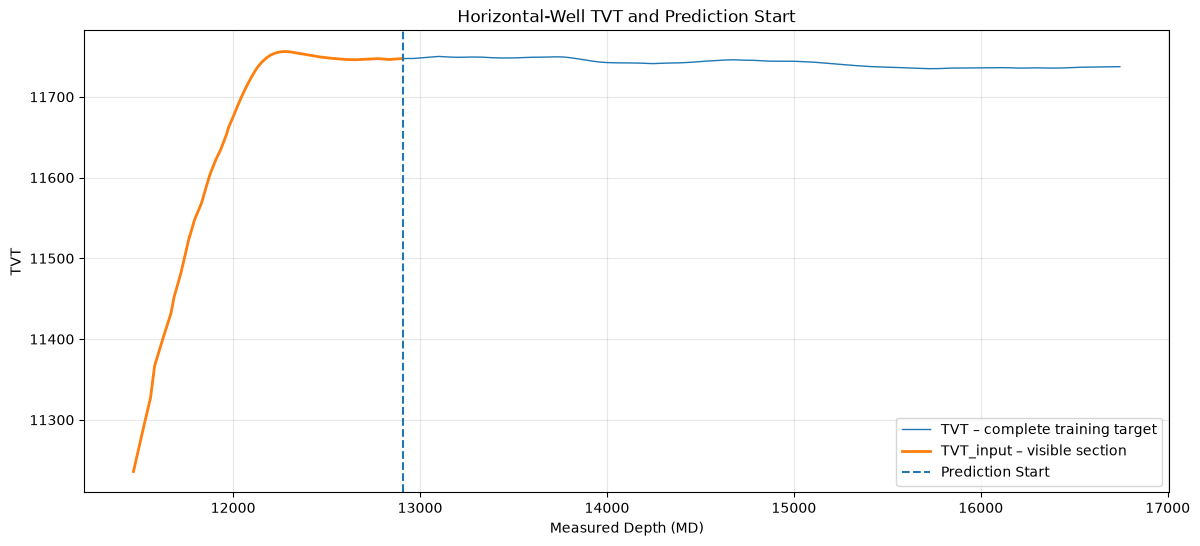

In [7]:
plt.figure(figsize=(14, 6))

plt.plot(
    horizontal["MD"],
    horizontal["TVT"],
    linewidth=1,
    label="TVT – complete training target"
)

plt.plot(
    horizontal["MD"],
    horizontal["TVT_input"],
    linewidth=2,
    label="TVT_input – visible section"
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Horizontal-Well TVT and Prediction Start")
plt.xlabel("Measured Depth (MD)")
plt.ylabel("TVT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### 8. Missing-value analysis

In [8]:
def missing_summary(dataframe):
    missing_count = dataframe.isna().sum()
    missing_percent = missing_count / len(dataframe) * 100

    return pd.DataFrame({
        "Missing Count": missing_count,
        "Missing Percentage": missing_percent.round(2)
    }).sort_values("Missing Count", ascending=False)


print("Typewell missing values")
display(missing_summary(typewell))

print("Horizontal-well missing values")
display(missing_summary(horizontal))

Typewell missing values


,Missing Count,Missing Percentage
Geology,299,23.0700
TVT,0,0.0000
GR,0,0.0000


Horizontal-well missing values


,Missing Count,Missing Percentage
TVT_input,3836,72.6800
GR,2258,42.7800
Y,0,0.0000
X,0,0.0000
MD,0,0.0000
ANCC,0,0.0000
Z,0,0.0000
ASTNU,0,0.0000
ASTNL,0,0.0000
EGFDL,0,0.0000


### 9. Plot missingness along MD

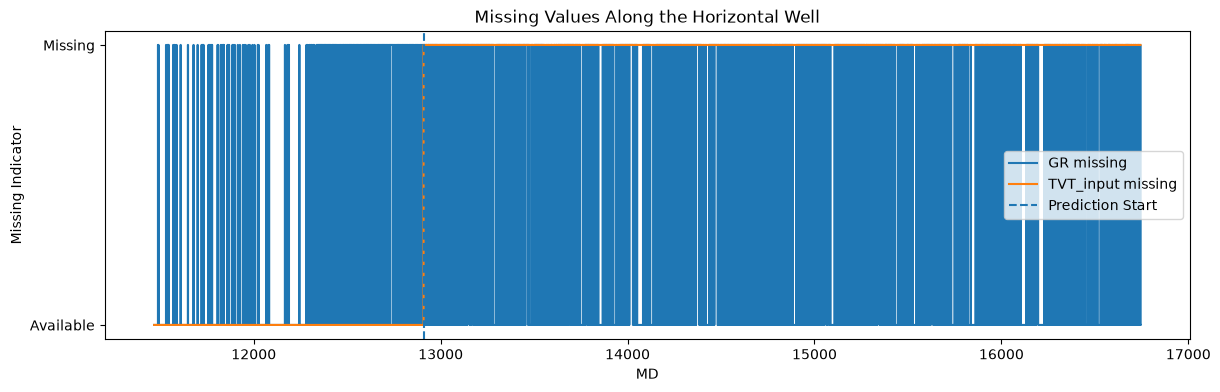

In [9]:
plt.figure(figsize=(14, 4))

plt.step(
    horizontal["MD"],
    horizontal["GR"].isna().astype(int),
    where="mid",
    label="GR missing"
)

plt.step(
    horizontal["MD"],
    horizontal["TVT_input"].isna().astype(int),
    where="mid",
    label="TVT_input missing"
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Missing Values Along the Horizontal Well")
plt.xlabel("MD")
plt.ylabel("Missing Indicator")
plt.yticks([0, 1], ["Available", "Missing"])
plt.legend()
plt.show()

## Typewell analysis

### 10. Typewell numerical summary and spacing

In [10]:
display(typewell[["TVT", "GR"]].describe().T)

typewell_tvt_spacing = typewell["TVT"].diff().dropna()

print("TVT spacing summary:")
display(typewell_tvt_spacing.describe())

,count,mean,std,min,25%,50%,75%,max
TVT,"1,296.0000","11,547.7000",187.1336,"11,223.9500","11,385.8250","11,547.7000","11,709.5750","11,871.4500"
GR,"1,296.0000",83.2576,26.2513,28.6600,64.9400,87.0900,102.8025,158.1800


TVT spacing summary:


count   1,295.0000
mean        0.5000
std         0.0000
min         0.5000
25%         0.5000
50%         0.5000
75%         0.5000
max         0.5000
Name: TVT, dtype: float64

### 11. Typewell geology distribution

Geology
ANCC     348
NaN      299
ASTNL    146
EGFDL    121
BUDA      96
LBHL      74
EGFDU     70
ASTNU     56
LTHL      31
LTGT      28
MNSS      27
Name: count, dtype: int64

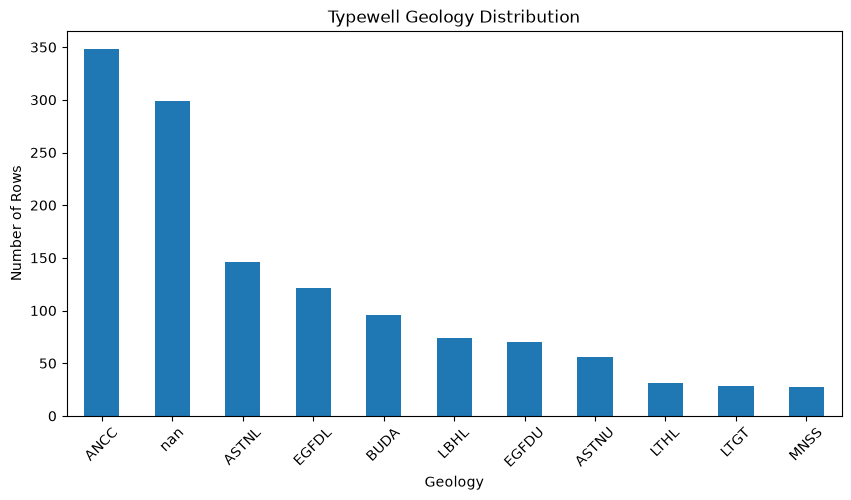

In [11]:
geology_counts = typewell["Geology"].value_counts(dropna=False)

display(geology_counts)

geology_counts.plot(kind="bar", figsize=(10, 5))

plt.title("Typewell Geology Distribution")
plt.xlabel("Geology")
plt.ylabel("Number of Rows")
plt.xticks(rotation=45)
plt.show()

### 12. Summarize geology by TVT range

In [12]:
geology_summary = (
    typewell
    .groupby("Geology", dropna=False)
    .agg(
        Row_Count=("TVT", "size"),
        TVT_Min=("TVT", "min"),
        TVT_Max=("TVT", "max"),
        GR_Mean=("GR", "mean"),
        GR_Std=("GR", "std"),
        GR_Min=("GR", "min"),
        GR_Max=("GR", "max")
    )
    .sort_values("TVT_Min")
)

display(geology_summary)

,Row_Count,TVT_Min,TVT_Max,GR_Mean,GR_Std,GR_Min,GR_Max
Geology,,,,,,,
NaN,299,"11,223.9500","11,372.9500",109.2268,13.3469,88.6800,158.1800
ANCC,348,"11,373.4500","11,546.9500",86.0911,16.7921,48.2900,118.6200
ASTNU,56,"11,547.4500","11,574.9500",79.8721,14.3959,59.1300,121.8000
ASTNL,146,"11,575.4500","11,647.9500",50.7731,15.0367,30.1200,123.1800
EGFDU,70,"11,648.4500","11,682.9500",62.6260,7.4173,48.6400,80.7800
EGFDL,121,"11,683.4500","11,743.4500",92.1890,14.0074,60.8600,128.4200
LTHL,31,"11,743.9500","11,758.9500",94.7974,14.5658,66.9500,130.7100
LTGT,28,"11,759.4500","11,772.9500",79.3639,7.4910,61.3000,91.2200
LBHL,74,"11,773.4500","11,809.9500",85.6672,15.1129,57.8700,120.8500


### 13. Plot typewell GR against TVT

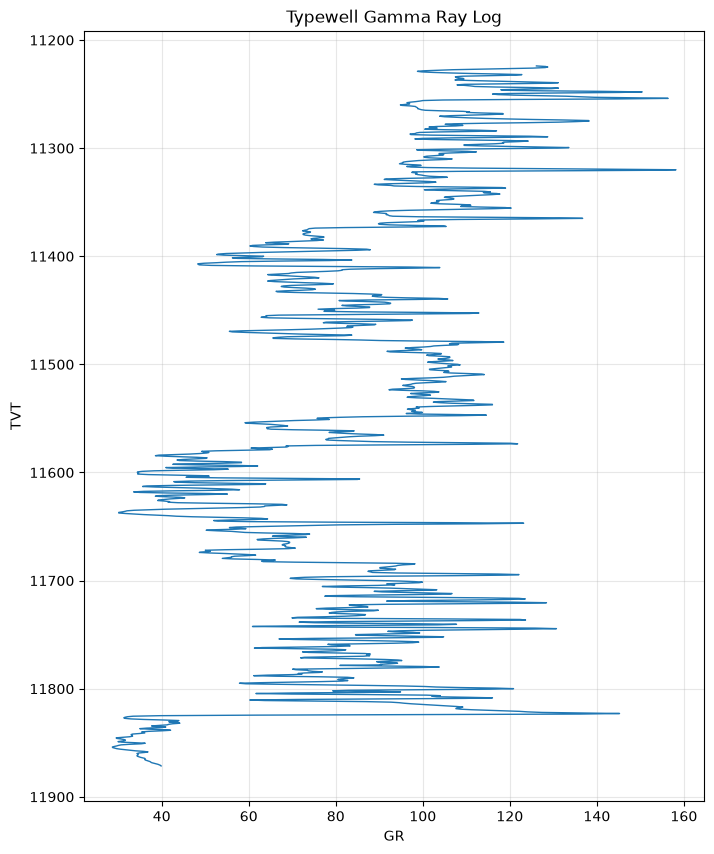

In [13]:
plt.figure(figsize=(8, 10))

plt.plot(typewell["GR"], typewell["TVT"], linewidth=1)

plt.gca().invert_yaxis()
plt.title("Typewell Gamma Ray Log")
plt.xlabel("GR")
plt.ylabel("TVT")
plt.grid(alpha=0.3)
plt.show()

## Horizontal-well analysis

### 14. MD sampling interval

In [14]:
horizontal_md_spacing = horizontal["MD"].diff().dropna()

display(horizontal_md_spacing.describe())

print("Most common MD intervals:")
display(horizontal_md_spacing.value_counts().head(10))

count   5,277.0000
mean        1.0000
std         0.0000
min         1.0000
25%         1.0000
50%         1.0000
75%         1.0000
max         1.0000
Name: MD, dtype: float64

Most common MD intervals:


MD
1.0000    5277
Name: count, dtype: int64

### 15. Plot horizontal-well trajectory

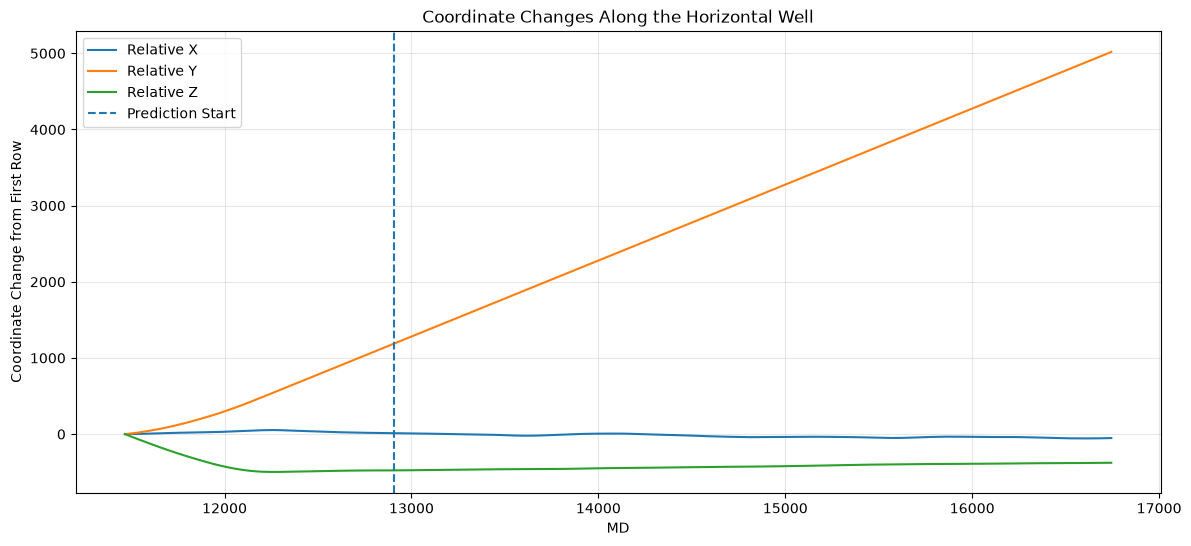

In [15]:
relative_coordinates = horizontal[["X", "Y", "Z"]].copy()

relative_coordinates["X"] -= relative_coordinates["X"].iloc[0]
relative_coordinates["Y"] -= relative_coordinates["Y"].iloc[0]
relative_coordinates["Z"] -= relative_coordinates["Z"].iloc[0]

plt.figure(figsize=(14, 6))

plt.plot(horizontal["MD"], relative_coordinates["X"], label="Relative X")
plt.plot(horizontal["MD"], relative_coordinates["Y"], label="Relative Y")
plt.plot(horizontal["MD"], relative_coordinates["Z"], label="Relative Z")

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Coordinate Changes Along the Horizontal Well")
plt.xlabel("MD")
plt.ylabel("Coordinate Change from First Row")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Target behaviour

### 16. Calculate TVT changes and slopes

In [17]:
horizontal_eda = horizontal.copy()

horizontal_eda["delta_MD"] = horizontal_eda["MD"].diff()
horizontal_eda["delta_TVT"] = horizontal_eda["TVT"].diff()

horizontal_eda["TVT_slope"] = (
    horizontal_eda["delta_TVT"]
    / horizontal_eda["delta_MD"]
)

horizontal_eda["Zone"] = np.where(
    known_tvt_mask,
    "Known Section",
    "Prediction Section"
)

display(
    horizontal_eda[
        ["MD", "TVT", "TVT_input", "delta_TVT", "TVT_slope", "Zone"]
    ].head()
)

,MD,TVT,TVT_input,delta_TVT,TVT_slope,Zone
0,"11,467.0000","11,236.0200","11,236.0200",NaN,NaN,Known Section
1,"11,468.0000","11,237.0500","11,237.0500",1.0300,1.0300,Known Section
2,"11,469.0000","11,238.0900","11,238.0900",1.0400,1.0400,Known Section
3,"11,470.0000","11,239.1200","11,239.1200",1.0300,1.0300,Known Section
4,"11,471.0000","11,240.1500","11,240.1500",1.0300,1.0300,Known Section


### 17. Count increasing, decreasing and flat TVT movements

Increasing            2040
Decreasing            1901
Approximately Flat    1336
dtype: int64

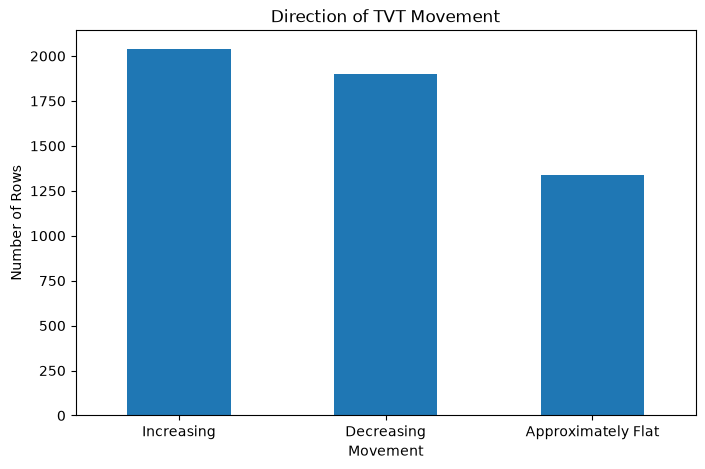

In [18]:
tolerance = 1e-6

direction_counts = pd.Series({
    "Increasing": (horizontal_eda["delta_TVT"] > tolerance).sum(),
    "Decreasing": (horizontal_eda["delta_TVT"] < -tolerance).sum(),
    "Approximately Flat": (
        horizontal_eda["delta_TVT"].abs() <= tolerance
    ).sum()
})

display(direction_counts)

direction_counts.plot(kind="bar", figsize=(8, 5))

plt.title("Direction of TVT Movement")
plt.xlabel("Movement")
plt.ylabel("Number of Rows")
plt.xticks(rotation=0)
plt.show()

### 18. Compare known and prediction sections

In [19]:
zone_summary = (
    horizontal_eda
    .groupby("Zone")
    .agg(
        Rows=("MD", "size"),
        MD_Min=("MD", "min"),
        MD_Max=("MD", "max"),
        TVT_Min=("TVT", "min"),
        TVT_Max=("TVT", "max"),
        TVT_Mean=("TVT", "mean"),
        TVT_Slope_Mean=("TVT_slope", "mean"),
        TVT_Slope_Std=("TVT_slope", "std"),
        GR_Available=("GR", "count")
    )
)

zone_summary["GR_Missing"] = (
    zone_summary["Rows"] - zone_summary["GR_Available"]
)

zone_summary["GR_Missing_Percentage"] = (
    zone_summary["GR_Missing"]
    / zone_summary["Rows"]
    * 100
)

display(zone_summary)

,Rows,MD_Min,MD_Max,TVT_Min,TVT_Max,TVT_Mean,TVT_Slope_Mean,TVT_Slope_Std,GR_Available,GR_Missing,GR_Missing_Percentage
Zone,,,,,,,,,,,
Known Section,1442,"11,467.0000","12,908.0000","11,236.0200","11,756.1200","11,646.4179",0.3549,0.4217,1000,442,30.6519
Prediction Section,3836,"12,909.0000","16,744.0000","11,734.8300","11,750.0300","11,741.9244",-0.0026,0.0126,2020,1816,47.3410


### 19. Plot TVT change along MD

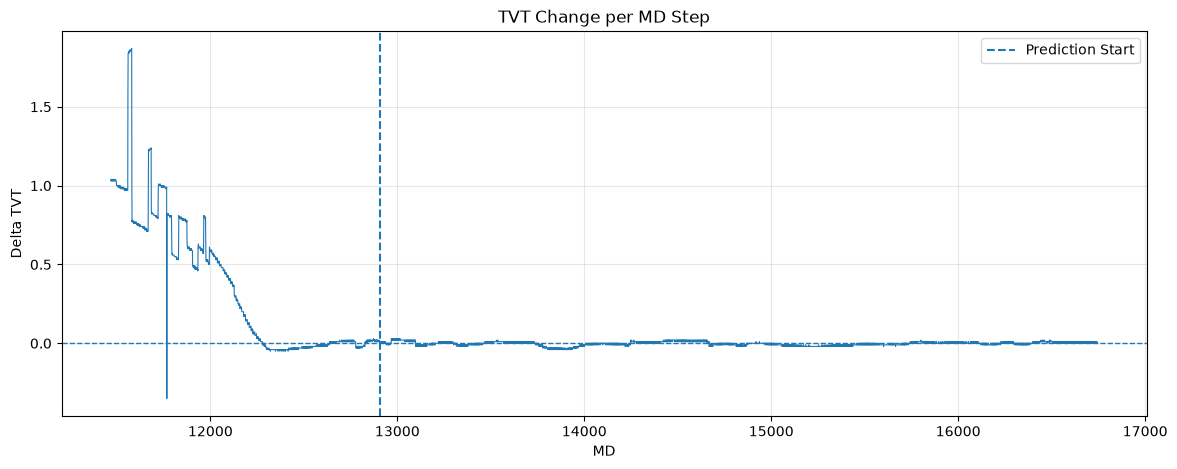

In [20]:
plt.figure(figsize=(14, 5))

plt.plot(
    horizontal_eda["MD"],
    horizontal_eda["delta_TVT"],
    linewidth=0.8
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("TVT Change per MD Step")
plt.xlabel("MD")
plt.ylabel("Delta TVT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## GR analysis

### 20. Horizontal GR distribution and availability

count   3,020.0000
mean       94.4370
std        18.6275
min        31.7658
25%        85.0683
50%        94.9365
75%       103.9609
max       217.3523
Name: GR, dtype: float64

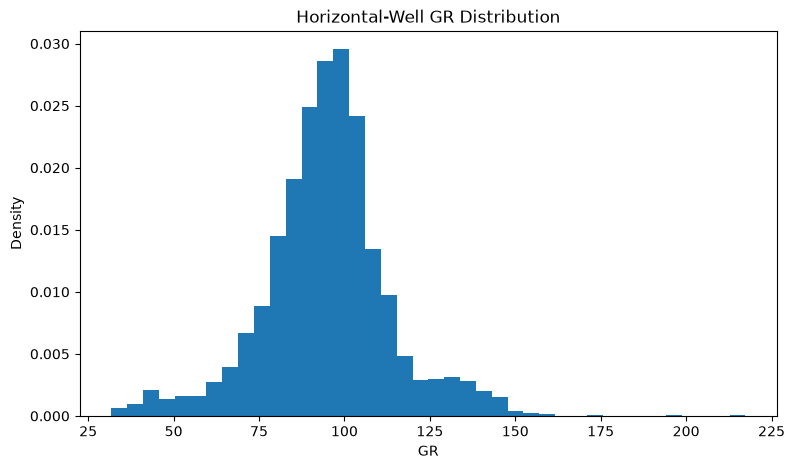

In [21]:
display(horizontal["GR"].describe())

plt.figure(figsize=(9, 5))

horizontal["GR"].dropna().plot(
    kind="hist",
    bins=40,
    density=True
)

plt.title("Horizontal-Well GR Distribution")
plt.xlabel("GR")
plt.ylabel("Density")
plt.show()

### 21. Plot GR along MD

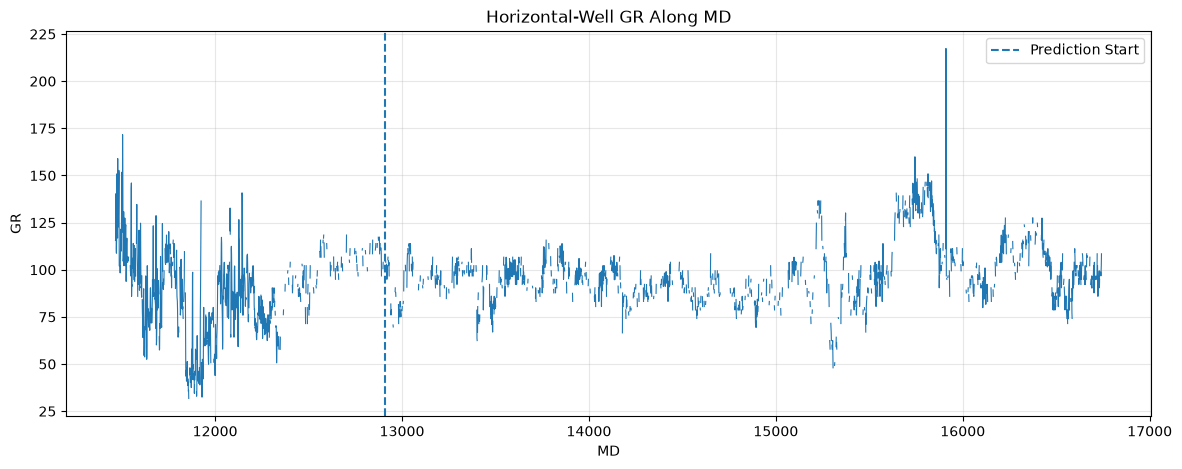

In [22]:
plt.figure(figsize=(14, 5))

plt.plot(
    horizontal["MD"],
    horizontal["GR"],
    linewidth=0.8
)

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Horizontal-Well GR Along MD")
plt.xlabel("MD")
plt.ylabel("GR")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Paired-well comparison

### 22. Compare TVT ranges

In [23]:
typewell_tvt_min = typewell["TVT"].min()
typewell_tvt_max = typewell["TVT"].max()

horizontal_tvt_min = horizontal["TVT"].min()
horizontal_tvt_max = horizontal["TVT"].max()

overlap_min = max(typewell_tvt_min, horizontal_tvt_min)
overlap_max = min(typewell_tvt_max, horizontal_tvt_max)

has_overlap = overlap_max >= overlap_min

horizontal_inside_typewell = (
    horizontal_tvt_min >= typewell_tvt_min
    and horizontal_tvt_max <= typewell_tvt_max
)

print("Typewell TVT range:")
print(typewell_tvt_min, "to", typewell_tvt_max)

print("\nHorizontal TVT range:")
print(horizontal_tvt_min, "to", horizontal_tvt_max)

print("\nOverlap:")
print(overlap_min, "to", overlap_max)

print("\nHas overlap:", has_overlap)
print("Horizontal range is inside typewell range:", horizontal_inside_typewell)

Typewell TVT range:
11223.95 to 11871.45

Horizontal TVT range:
11236.02 to 11756.12

Overlap:
11236.02 to 11756.12

Has overlap: True
Horizontal range is inside typewell range: True


### 23. Compare GR distributions correctly

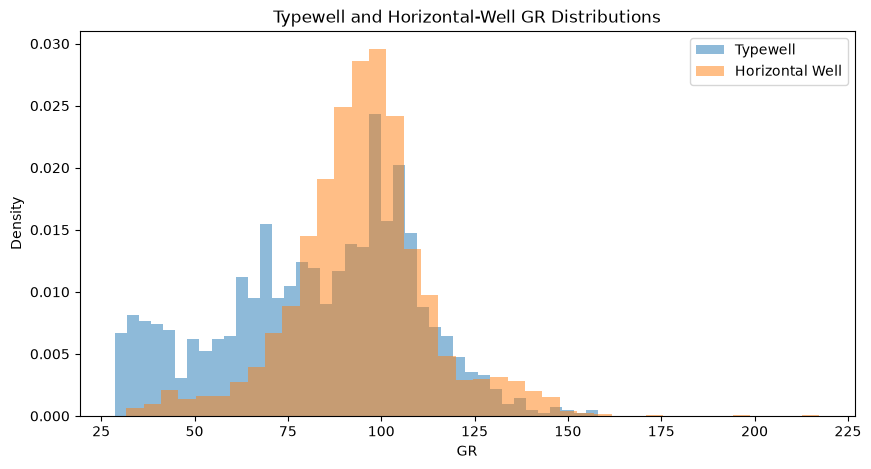

In [24]:
plt.figure(figsize=(10, 5))

plt.hist(
    typewell["GR"].dropna(),
    bins=40,
    density=True,
    alpha=0.5,
    label="Typewell"
)

plt.hist(
    horizontal["GR"].dropna(),
    bins=40,
    density=True,
    alpha=0.5,
    label="Horizontal Well"
)

plt.title("Typewell and Horizontal-Well GR Distributions")
plt.xlabel("GR")
plt.ylabel("Density")
plt.legend()
plt.show()

### 24. Compare GR against TVT by zone

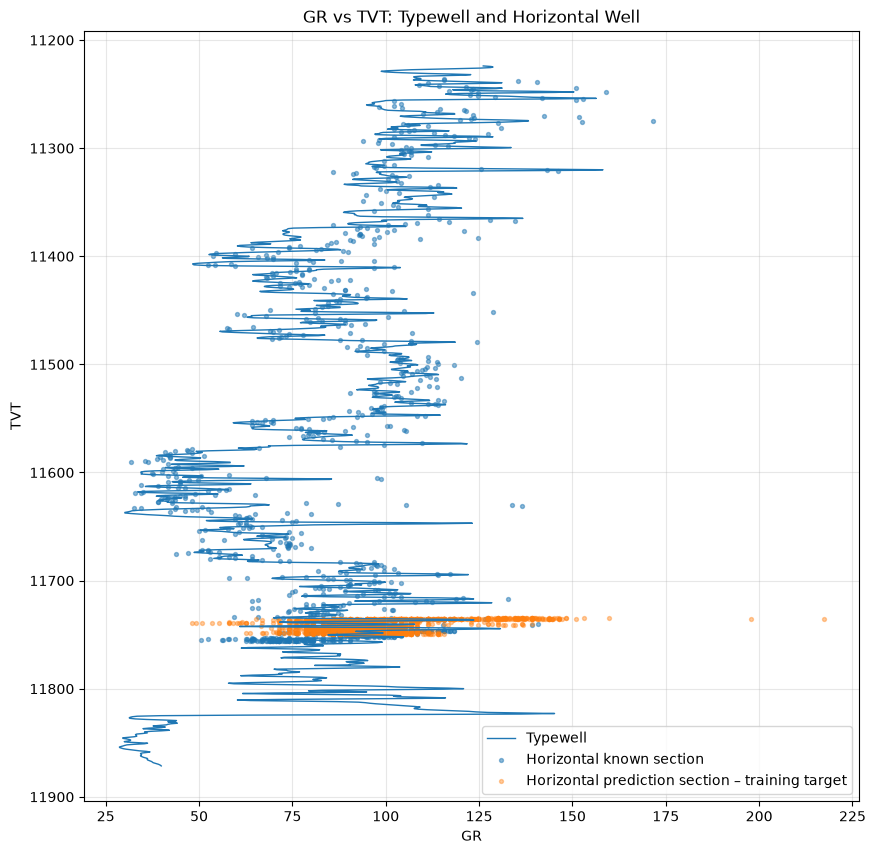

In [25]:
known_gr_mask = known_tvt_mask & horizontal["GR"].notna()
prediction_gr_mask = (~known_tvt_mask) & horizontal["GR"].notna()

plt.figure(figsize=(10, 10))

plt.plot(
    typewell["GR"],
    typewell["TVT"],
    linewidth=1,
    label="Typewell"
)

plt.scatter(
    horizontal.loc[known_gr_mask, "GR"],
    horizontal.loc[known_gr_mask, "TVT_input"],
    s=8,
    alpha=0.5,
    label="Horizontal known section"
)

plt.scatter(
    horizontal.loc[prediction_gr_mask, "GR"],
    horizontal.loc[prediction_gr_mask, "TVT"],
    s=8,
    alpha=0.4,
    label="Horizontal prediction section – training target"
)

plt.gca().invert_yaxis()
plt.title("GR vs TVT: Typewell and Horizontal Well")
plt.xlabel("GR")
plt.ylabel("TVT")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Formation columns

### 25. Correctly identify column groups

In [26]:
trajectory_columns = ["MD", "X", "Y", "Z"]
formation_columns = [
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA"
]
log_columns = ["GR"]
target_columns = ["TVT", "TVT_input"]

print("Trajectory columns:", trajectory_columns)
print("Formation columns:", formation_columns)
print("Log columns:", log_columns)
print("Target columns:", target_columns)

Trajectory columns: ['MD', 'X', 'Y', 'Z']
Formation columns: ['ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA']
Log columns: ['GR']
Target columns: ['TVT', 'TVT_input']


In [27]:
available_formation_columns = [
    column
    for column in formation_columns
    if column in horizontal.columns
]

display(
    horizontal[available_formation_columns]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
ANCC,"5,278.0000","-9,330.6218",35.2730,"-9,395.8100","-9,362.3075","-9,335.9750","-9,296.6650","-9,271.0000"
ASTNU,"5,278.0000","-9,504.6718",35.2730,"-9,569.8600","-9,536.3575","-9,510.0250","-9,470.7150","-9,445.0500"
ASTNL,"5,278.0000","-9,532.4518",35.2730,"-9,597.6400","-9,564.1375","-9,537.8050","-9,498.4950","-9,472.8300"
EGFDU,"5,278.0000","-9,605.8018",35.2730,"-9,670.9900","-9,637.4875","-9,611.1550","-9,571.8450","-9,546.1800"
EGFDL,"5,278.0000","-9,640.7718",35.2730,"-9,705.9600","-9,672.4575","-9,646.1250","-9,606.8150","-9,581.1500"
BUDA,"5,278.0000","-9,781.1618",35.2730,"-9,846.3500","-9,812.8475","-9,786.5150","-9,747.2050","-9,721.5400"


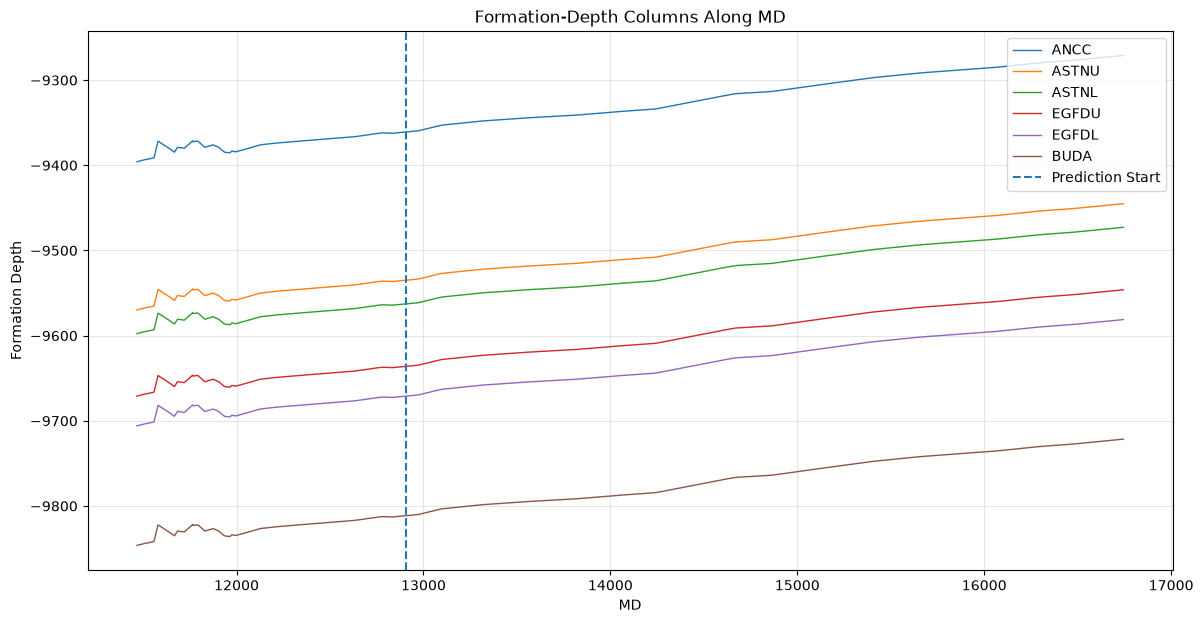

In [28]:
plt.figure(figsize=(14, 7))

for column in available_formation_columns:
    plt.plot(
        horizontal["MD"],
        horizontal[column],
        label=column,
        linewidth=1
    )

if prediction_start_md is not None:
    plt.axvline(
        prediction_start_md,
        linestyle="--",
        label="Prediction Start"
    )

plt.title("Formation-Depth Columns Along MD")
plt.xlabel("MD")
plt.ylabel("Formation Depth")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Correlation analysis

### 26. Selected correlation table

In [29]:
correlation_columns = [
    "MD",
    "X",
    "Y",
    "Z",
    "GR",
    "TVT_input",
    "TVT"
]

correlation_columns = [
    column
    for column in correlation_columns
    if column in horizontal_eda.columns
]

correlation_matrix = (
    horizontal_eda[correlation_columns]
    .corr()
    .round(3)
)

display(correlation_matrix)

,MD,X,Y,Z,GR,TVT_input,TVT
MD,1.0000,-0.9050,1.0000,-0.0580,0.3180,0.8470,0.4480
X,-0.9050,1.0000,-0.9100,-0.1910,-0.3290,0.7070,-0.1900
Y,1.0000,-0.9100,1.0000,-0.0350,0.3240,0.7860,0.4280
Z,-0.0580,-0.1910,-0.0350,1.0000,0.1250,-0.9990,-0.9180
GR,0.3180,-0.3290,0.3240,0.1250,1.0000,-0.2370,0.0010
TVT_input,0.8470,0.7070,0.7860,-0.9990,-0.2370,1.0000,1.0000
TVT,0.4480,-0.1900,0.4280,-0.9180,0.0010,1.0000,1.0000


### 27. final sample summary

In [30]:
sample_summary = pd.Series({
    "Well ID": sample_id,
    "Typewell Rows": len(typewell),
    "Horizontal Rows": len(horizontal),
    "Known TVT Rows": known_rows,
    "Prediction Rows": prediction_rows,
    "Prediction Percentage": round(prediction_percentage, 2),
    "Horizontal GR Missing Percentage": round(
        horizontal["GR"].isna().mean() * 100,
        2
    ),
    "Clean Prediction Boundary": clean_boundary,
    "TVT_input Matches TVT": tvt_input_matches_target,
    "Typewell Covers Horizontal TVT": horizontal_inside_typewell
})

display(sample_summary.to_frame("Value"))

,Value
Well ID,000d7d20_
Typewell Rows,1296
Horizontal Rows,5278
Known TVT Rows,1442
Prediction Rows,3836
Prediction Percentage,72.6800
Horizontal GR Missing Percentage,42.7800
Clean Prediction Boundary,True
TVT_input Matches TVT,True
Typewell Covers Horizontal TVT,True


### 28. EDA Conclusions for the Selected Well Pair

- The typewell and horizontal-well files form a valid paired dataset.
- The typewell provides a geological reference using TVT, GR, and formation labels.
- The horizontal well contains trajectory measurements, GR values, known `TVT_input`, and the complete training target `TVT`.
- `TVT_input` is available before the Prediction Start point and becomes missing continuously afterward.
- The missing `TVT_input` section represents the rows where TVT must be predicted.
- The last known TVT and the recent TVT trend provide useful starting information for prediction.
- TVT can increase, decrease, or remain approximately flat along MD, so MD alone cannot reliably predict TVT.
- GR contains useful geological patterns, but missing GR values mean the model should not depend only on GR.
- X, Y, and Z describe the well trajectory and may help explain changes in TVT.
- The typewell and horizontal-well GR patterns may help align the horizontal well with the geological TVT scale.
- Correlation values provide an initial view of linear relationships, but they do not fully represent nonlinear or sequence-based relationships.
- The full horizontal-well `TVT` column must only be used as the training target and must not be included as a model input.
- These observations are based on one well pair and must next be validated across all 773 training pairs.
